<a href="https://colab.research.google.com/github/KelseyWang2022/1.YOLO/blob/main/roundabout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Number of scenarios: 22
Entries per scenario:
Entry
4    22
Name: count, dtype: int64

Scenario-level Wilcoxon results:
       Comparison  Wilcoxon statistic  p-value  Mean difference: reference - Combined  Median difference: reference - Combined  Scenarios where Combined is better  Scenarios where Combined is worse
Combined vs Swiss                16.0 0.000081                              35.884670                                14.428718                                  19                                  3
  Combined vs HCM                49.0 0.010324                               9.018165                                 8.056922                                  14                                  8


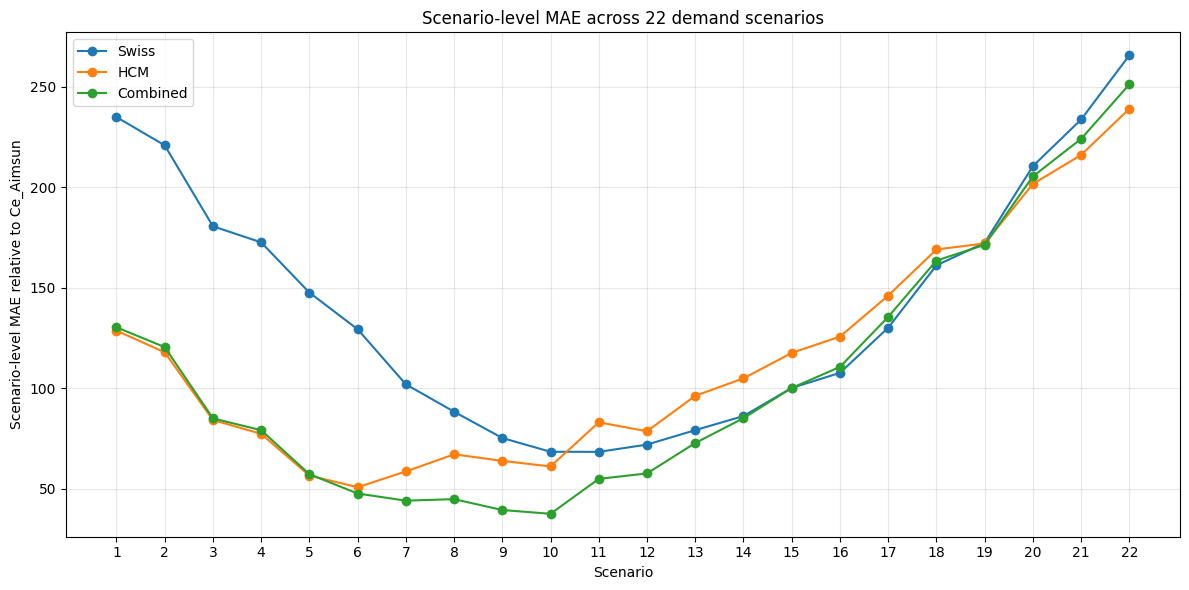

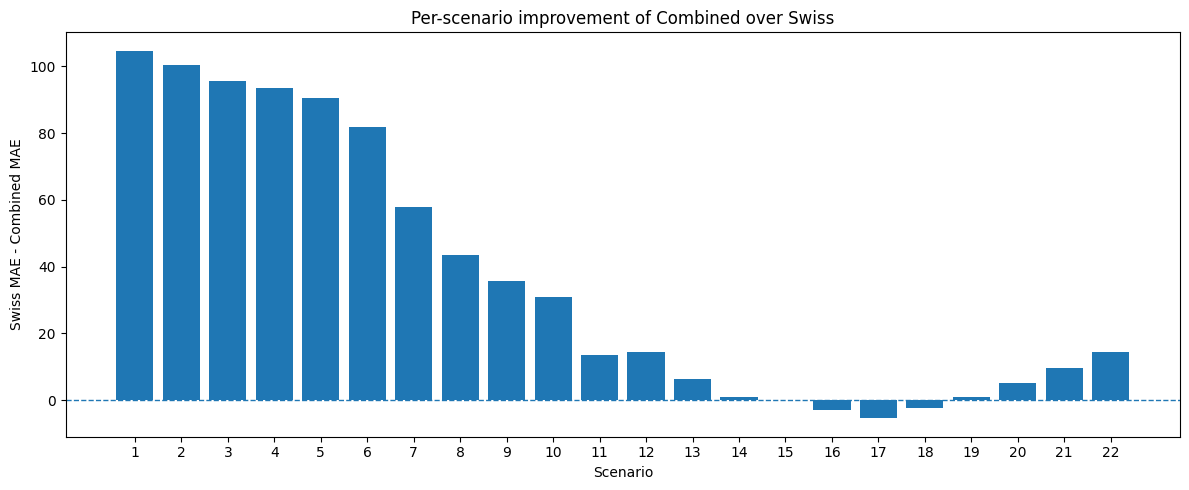

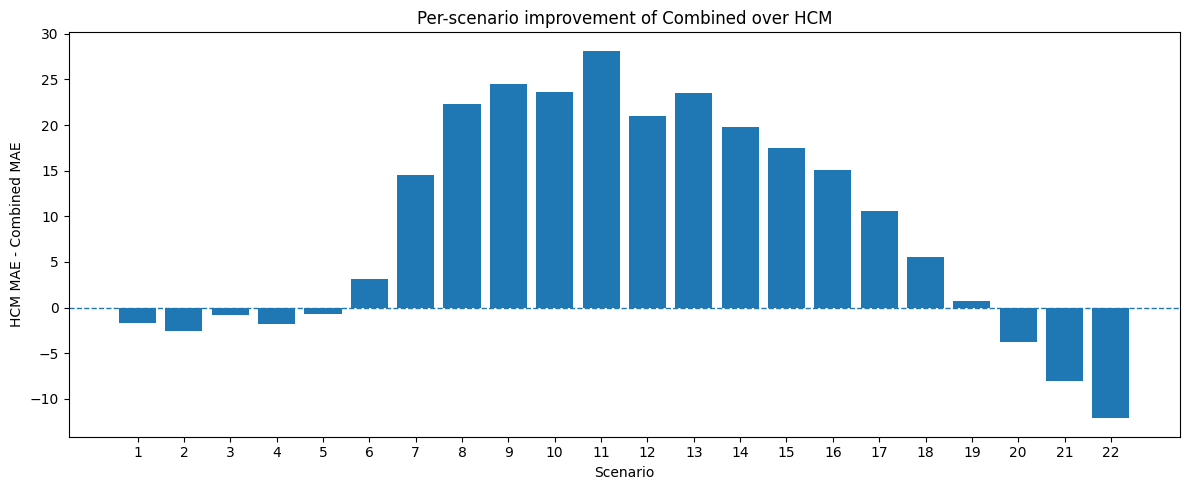

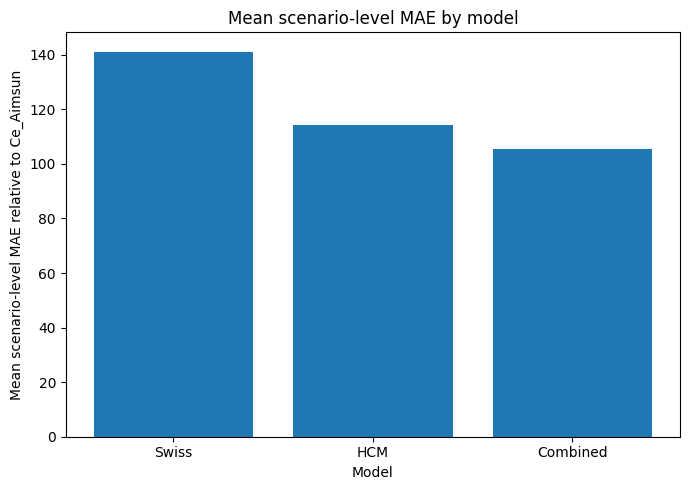


Saved files in:
/content/scenario_level_results


In [2]:
import pandas as pd
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# 1. File settings
# =========================

file_path = Path("/content/d. Algorithm Application (absolute error) and Final Results_22 cases.xlsx")
sheet_name = "Calculation"

output_dir = Path("scenario_level_results")
output_dir.mkdir(exist_ok=True)

# =========================
# 2. Read data
# =========================

df = pd.read_excel(file_path, sheet_name=sheet_name, header=1)

df = df.dropna(
    subset=["Entry", "Ce_Aimsun", "Ce_Swiss", "Ce_HCM", "Ce_Combined"]
).copy()

df["Scenario"] = df["Roundabout"].ffill().astype(int)

# =========================
# 3. Check data structure
# =========================

n_scenarios = df["Scenario"].nunique()
entries_per_scenario = df.groupby("Scenario")["Entry"].count()

print(f"Number of scenarios: {n_scenarios}")
print("Entries per scenario:")
print(entries_per_scenario.value_counts().sort_index())

if n_scenarios != 22:
    raise ValueError(f"Expected 22 scenarios, but found {n_scenarios}.")

if not (entries_per_scenario == 4).all():
    raise ValueError("Not every scenario has exactly 4 entries.")

# =========================
# 4. Compute absolute errors
#    Reference = Ce_Aimsun
# =========================

df["Swiss_abs_error"] = (df["Ce_Swiss"] - df["Ce_Aimsun"]).abs()
df["HCM_abs_error"] = (df["Ce_HCM"] - df["Ce_Aimsun"]).abs()
df["Combined_abs_error"] = (df["Ce_Combined"] - df["Ce_Aimsun"]).abs()

# =========================
# 5. Scenario-level MAE
# =========================

scenario_errors = (
    df.groupby("Scenario", as_index=False)
      .agg(
          Swiss_MAE=("Swiss_abs_error", "mean"),
          HCM_MAE=("HCM_abs_error", "mean"),
          Combined_MAE=("Combined_abs_error", "mean")
      )
)

# Positive value means Combined is better
scenario_errors["Swiss_minus_Combined"] = (
    scenario_errors["Swiss_MAE"] - scenario_errors["Combined_MAE"]
)

scenario_errors["HCM_minus_Combined"] = (
    scenario_errors["HCM_MAE"] - scenario_errors["Combined_MAE"]
)

# =========================
# 6. Wilcoxon paired tests
# =========================

swiss_test = wilcoxon(
    scenario_errors["Swiss_MAE"],
    scenario_errors["Combined_MAE"],
    alternative="two-sided"
)

hcm_test = wilcoxon(
    scenario_errors["HCM_MAE"],
    scenario_errors["Combined_MAE"],
    alternative="two-sided"
)

summary = pd.DataFrame({
    "Comparison": ["Combined vs Swiss", "Combined vs HCM"],
    "Wilcoxon statistic": [
        swiss_test.statistic,
        hcm_test.statistic
    ],
    "p-value": [
        swiss_test.pvalue,
        hcm_test.pvalue
    ],
    "Mean difference: reference - Combined": [
        scenario_errors["Swiss_minus_Combined"].mean(),
        scenario_errors["HCM_minus_Combined"].mean()
    ],
    "Median difference: reference - Combined": [
        scenario_errors["Swiss_minus_Combined"].median(),
        scenario_errors["HCM_minus_Combined"].median()
    ],
    "Scenarios where Combined is better": [
        (scenario_errors["Swiss_minus_Combined"] > 0).sum(),
        (scenario_errors["HCM_minus_Combined"] > 0).sum()
    ],
    "Scenarios where Combined is worse": [
        (scenario_errors["Swiss_minus_Combined"] < 0).sum(),
        (scenario_errors["HCM_minus_Combined"] < 0).sum()
    ]
})

print("\nScenario-level Wilcoxon results:")
print(summary.to_string(index=False))

# =========================
# 7. Save tables
# =========================

scenario_errors.to_csv(output_dir / "scenario_level_errors.csv", index=False)
summary.to_csv(output_dir / "wilcoxon_summary.csv", index=False)

# =========================
# 8. Figure 1:
# Scenario-level MAE by model
# =========================

plt.figure(figsize=(12, 6))

plt.plot(
    scenario_errors["Scenario"],
    scenario_errors["Swiss_MAE"],
    marker="o",
    label="Swiss"
)

plt.plot(
    scenario_errors["Scenario"],
    scenario_errors["HCM_MAE"],
    marker="o",
    label="HCM"
)

plt.plot(
    scenario_errors["Scenario"],
    scenario_errors["Combined_MAE"],
    marker="o",
    label="Combined"
)

plt.xlabel("Scenario")
plt.ylabel("Scenario-level MAE relative to Ce_Aimsun")
plt.title("Scenario-level MAE across 22 demand scenarios")
plt.xticks(scenario_errors["Scenario"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "scenario_level_mae_by_model.png", dpi=300)
plt.show()

# =========================
# 9. Figure 2:
# Combined vs Swiss difference
# =========================

plt.figure(figsize=(12, 5))
plt.axhline(0, linestyle="--", linewidth=1)

plt.bar(
    scenario_errors["Scenario"].astype(str),
    scenario_errors["Swiss_minus_Combined"]
)

plt.xlabel("Scenario")
plt.ylabel("Swiss MAE - Combined MAE")
plt.title("Per-scenario improvement of Combined over Swiss")
plt.tight_layout()
plt.savefig(output_dir / "combined_vs_swiss_difference.png", dpi=300)
plt.show()

# =========================
# 10. Figure 3:
# Combined vs HCM difference
# =========================

plt.figure(figsize=(12, 5))
plt.axhline(0, linestyle="--", linewidth=1)

plt.bar(
    scenario_errors["Scenario"].astype(str),
    scenario_errors["HCM_minus_Combined"]
)

plt.xlabel("Scenario")
plt.ylabel("HCM MAE - Combined MAE")
plt.title("Per-scenario improvement of Combined over HCM")
plt.tight_layout()
plt.savefig(output_dir / "combined_vs_hcm_difference.png", dpi=300)
plt.show()

# =========================
# 11. Figure 4:
# Mean scenario-level MAE
# =========================

mean_mae = pd.DataFrame({
    "Model": ["Swiss", "HCM", "Combined"],
    "Mean scenario-level MAE": [
        scenario_errors["Swiss_MAE"].mean(),
        scenario_errors["HCM_MAE"].mean(),
        scenario_errors["Combined_MAE"].mean()
    ]
})

plt.figure(figsize=(7, 5))

plt.bar(
    mean_mae["Model"],
    mean_mae["Mean scenario-level MAE"]
)

plt.xlabel("Model")
plt.ylabel("Mean scenario-level MAE relative to Ce_Aimsun")
plt.title("Mean scenario-level MAE by model")
plt.tight_layout()
plt.savefig(output_dir / "mean_scenario_level_mae_by_model.png", dpi=300)
plt.show()

print("\nSaved files in:")
print(output_dir.resolve())